# Delivery Performance Analysis

## Goal

This notebook analyzes delivery performance based on the available logistics data. The goal is to examine delivery times and delays, and to identify potential differences between regions and transport types.

The following questions are examined:

1. What is the average delivery duration?
2. How often are deliveries delayed?
3. Which regions have particularly long delivery times?
4. Which equipment types are particularly fast or slow?
5. Are there specific regions with an above-average number of delays?

To answer these questions, the relevant tables are first merged, then cleaned and analyzed. The results are presented through appropriate visualizations.

## Data Basis

The analysis primarily uses the following tables:

- `loads` - information about the shipments
- `trips` - information about the trips carried out
- `delivery_events` - information about pickup and delivery
- `routes` - information about the respective routes

The tables are related as follows:

- `delivery_events`-(`trip_id`)->`trips`-(`load_id`)->`loads`-(`route_id`)->`routes`
- `delivery_events`-(`load_id`)->`loads`

Data cleaning, merging, and metric calculation (`delivery_duration_hours`, `delivery_delay_hours`, `is_delayed_delivery`) happen in `src/delivery_pipeline.py`, not in this notebook. This notebook loads the already-cleaned result and focuses on analysis and visualization.

## 1. Load Data (via Pipeline)

In [21]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from delivery_pipeline import run_pipeline

clean_df = run_pipeline()
print(f"Loads used for analysis: {len(clean_df)}")


2026-09-10 22:09:37,773 | INFO | loads: loaded 85410 rows, 12 columns
2026-09-10 22:09:38,593 | INFO | trips: loaded 85410 rows, 12 columns
2026-09-10 22:09:41,163 | INFO | delivery_events: loaded 170820 rows, 11 columns
2026-09-10 22:09:41,238 | INFO | routes: loaded 58 rows, 9 columns
2026-09-10 22:09:42,048 | INFO | Merged table: 170820 rows, 41 columns
2026-09-10 22:09:43,663 | INFO | Flattened to 85410 loads (from 170820 event rows)
2026-09-10 22:09:43,843 | INFO | Removed 486 loads with inconsistent timestamps (0.57%)
2026-09-10 22:09:48,714 | INFO | Saved cleaned data to D:\Documents\Portfolio\smart-logistics-analytics\data\processed\clean_delivery_performance.csv (84924 rows)


Loads used for analysis: 84924


*Note on data cleaning: Loads where the actual delivery timestamp is before the actual pickup timestamp were already excluded in the pipeline (see `drop_inconsistent_timestamps()` in `delivery_pipeline.py`). The raw data itself is not modified; less than 1% of loads were affected.*

### Data Quality Note

During timestamp validation, an edge case was found: one delivery had a rounded `delivery_duration_hours` value of 0.0, even though the exact timestamp comparison showed a (minimal) negative difference between the delivery and pickup timestamps. A plain filter on `delivery_duration_hours >= 0` would have let this inconsistent record pass as valid.

The check is therefore consistently performed on the unrounded timestamps (`delivery_actual_datetime >= pickup_actual_datetime`), not on the already rounded, derived metric - see `drop_inconsistent_timestamps()` in `delivery_pipeline.py`.

## 2. Delivery Duration and Punctuality

### 2.1 What is the average delivery duration?
### 2.2 How often are deliveries delayed?
### 2.3 How large are the delays?

In [22]:
delayed_trips = clean_df[clean_df["is_delayed_delivery"]]
share_delayed = clean_df["is_delayed_delivery"].mean() * 100

print("Delivery duration")
display(clean_df["delivery_duration_hours"].describe().round(2))

print(f"\n Punctuality ({len(clean_df)} deliveries total)")
print(f"Delayed deliveries: {clean_df['is_delayed_delivery'].sum()} ({share_delayed:.2f}%)")

print("\nDelay duration (delayed deliveries only)")
display(delayed_trips["delivery_delay_hours"].describe().round(2))

Delivery duration


count    84924.00
mean        26.68
std         14.32
min          0.00
25%         14.62
50%         24.88
75%         38.53
max         73.77
Name: delivery_duration_hours, dtype: float64


 Punctuality (84924 deliveries total)
Delayed deliveries: 56933 (67.04%)

Delay duration (delayed deliveries only)


count    56933.00
mean         3.00
std          1.74
min          0.01
25%          1.51
50%          3.00
75%          4.51
max          6.00
Name: delivery_delay_hours, dtype: float64

## 3. Charts

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(clean_df["delivery_duration_hours"], bins=30)
ax.axvline(
    clean_df["delivery_duration_hours"].median(),
    color="red", linestyle="--",
    label=f"Median: {clean_df['delivery_duration_hours'].median():.1f}h",
)
ax.set_xlabel("Delivery duration (hours)")
ax.set_ylabel("Number of deliverys")
ax.set_title("Distribution of delivery duration")
ax.legend()
plt.show()

*[Interpretation placeholder]*

In [ ]:
delay_counts = clean_df["is_delayed_delivery"].value_counts()
labels = ["On-time / early", "Delayed"]
values = [delay_counts.get(False, 0), delay_counts.get(True, 0)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values)
ax.bar_label(bars, labels=[f"{v} ({v/sum(values)*100:.1f}%)" for v in values])
ax.set_ylabel("Number of deliveries")
ax.set_title("Delivery punctuality")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(delayed_trips["delivery_delay_hours"], bins=30)
ax.set_xlabel("Delay (hours)")
ax.set_ylabel("Number of deliveries")
ax.set_title("Distribution of delay duration (delayed deliveries only)")
plt.show()

*[Interpretation placeholder]*

## 4. Regional Differences

### 4.1 Which regions have particularly long delivery times and an above-average share of delays?

In [23]:
region_stats = (
    clean_df.groupby("delivery_location_state")
    .agg(
        avg_duration_hours=("delivery_duration_hours", "mean"),
        delayed_share=("is_delayed_delivery", "mean"),
        avg_delay_hours=("delivery_delay_hours", lambda s: s[s > 0].mean()),
        n_loads=("load_id", "size"),
    )
    .round(2)
    .sort_values("delayed_share", ascending=False)
)
display(region_stats)

,avg_duration_hours,delayed_share,avg_delay_hours,n_loads
delivery_location_state,,,,
NY,28.35,0.71,3.03,4255
PA,20.77,0.70,2.98,5894
MO,18.90,0.68,2.98,5889
CA,30.53,0.67,3.03,8948
CO,23.87,0.67,2.95,5863
IN,20.49,0.67,3.02,5810
NV,32.99,0.67,2.98,1479
TX,27.42,0.67,3.00,7277
MN,17.44,0.67,3.06,4424


### 4.2 Delay frequency vs. delay severity

The two metrics `delayed_share` and `avg_delay_hours` can be visualized separately (clear per-metric comparison) or combined (to spot regions that struggle on both dimensions at once). Both views are shown below.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, max(4, len(region_stats) * 0.4)))
ax[0].barh(region_stats.index, region_stats["delayed_share"] * 100)
ax[0].set_xlabel("Share of delayed deliveries (%)")
ax[0].set_title("Delay rate by region")
ax[0].invert_yaxis() 

ax[1].barh(region_stats.index, region_stats["avg_delay_hours"], color="tab:orange")
ax[1].set_xlabel("Avg. delay (hours)")
ax[1].set_title("Average delay severity by region")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

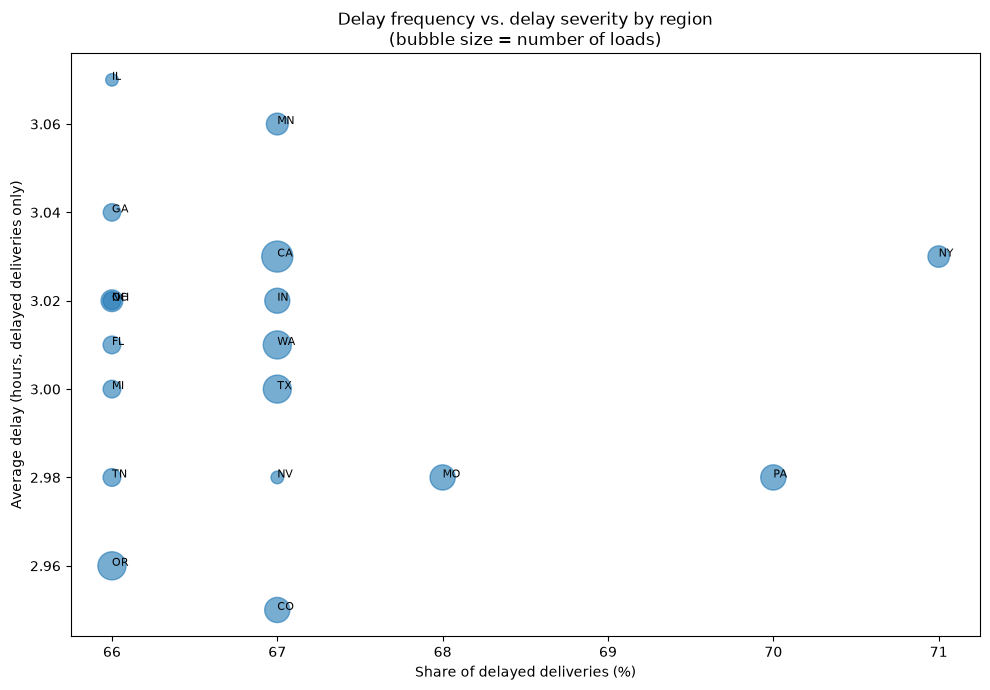

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    region_stats["delayed_share"] * 100,
    region_stats["avg_delay_hours"],
    s=region_stats["n_loads"] / region_stats["n_loads"].max() * 500,  
    alpha=0.6,
)

for state, row in region_stats.iterrows():
    ax.annotate(state, (row["delayed_share"] * 100, row["avg_delay_hours"]), fontsize=8)

ax.set_xlabel("Share of delayed deliveries (%)")
ax.set_ylabel("Average delay (hours, delayed deliveries only)")
ax.set_title("Delay frequency vs. delay severity by region\n(bubble size = number of loads)")
plt.tight_layout()
plt.show()

*While the bar charts show each metric individually, the scatter plot reveals that NY stands out not just for a high delay rate, but also for comparatively severe delays once they occur - making it the most critical region to investigate further.*

## 5. Differences by Equipment Type

### 5.1 Which equipment types (Dry Van vs. Refrigerated) show different delivery durations or delay rates?

In [ ]:
transport_column = "load_type" 

mode_stats = (
    clean_df.groupby(transport_column)
    .agg(
        avg_duration_hours=("delivery_duration_hours", "mean"),
        delayed_share=("is_delayed_delivery", "mean"),
        n_loads=("load_id", "size"),
    )
    .round(2)
    .sort_values("delayed_share", ascending=False)
)  
display(mode_stats)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, max(4, len(mode_stats) * 0.4)))

axes[0].barh(mode_stats.index, mode_stats["avg_duration_hours"])
axes[0].set_xlabel("Avg. delivery duration (hours)")
axes[0].set_title("Delivery duration by transport type")
axes[0].invert_yaxis()

axes[1].barh(mode_stats.index, mode_stats["delayed_share"] * 100, color="tab:orange")
axes[1].set_xlabel("Share of delayed deliveries (%)")
axes[1].set_title("Delay rate by transport type")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

*[Interpretation placeholder]*

## 6. Conclusion

*[Brief summary of the key findings for the questions raised at the beginning]*